In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
import scipy as sp
import pandas as pd
from statsmodels.graphics.gofplots import qqplot


## Задача 1. 
Генерирайте 1000 наблюдения над нормално разпределена случайна величина със средно 5 и вариация 12. Начертаите Q-Q plot на наблюденията спрямо разпределението, от което са избрани.

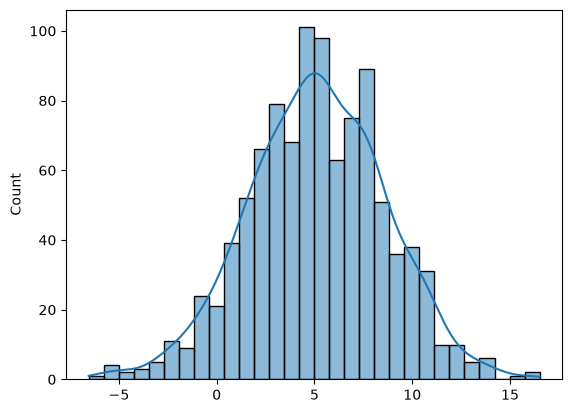

In [2]:
rng = np.random.default_rng(seed=3) # За да възпроизведем резултатите, използваме фиксиран seed

mu = 5
var = 12
sigma = np.sqrt(var)

norm_sample = rng.normal(mu, sigma, 1000)

sb.histplot(norm_sample, bins=30, kde=True)
plt.show()

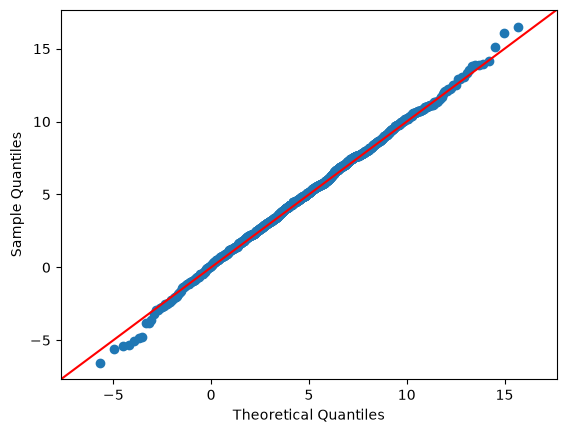

In [3]:
plot = qqplot(norm_sample, line='45', loc=mu, scale=sigma)

## Задача 2. 
Имплементирайте фунцкия, която начертава Q-Q plot спрямо нормалното разпределение от подадени едномерни данни

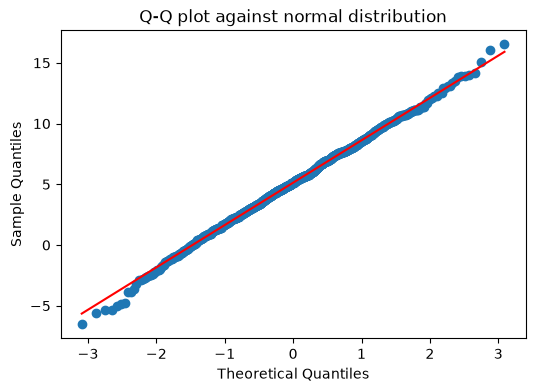

In [4]:
def custom_qqplot_normal(sample):
    n = len(sample)

    ordered = np.sort(sample)
    index = np.arange(1, n + 1)

    probabilities = index / (n + 1)
    th_quantiles = sp.stats.norm.ppf(probabilities)

    x_line = np.array([th_quantiles.min(), th_quantiles.max()])
    y_line = sample.mean() + x_line*sample.std()

    plt.figure(figsize=(6, 4))
    plt.scatter(th_quantiles, ordered)
    plt.plot(x_line, y_line, color="red")
    plt.xlabel("Theoretical Quantiles")
    plt.ylabel("Sample Quantiles")
    plt.title("Q-Q plot against normal distribution")
    plt.show()

custom_qqplot_normal(norm_sample)

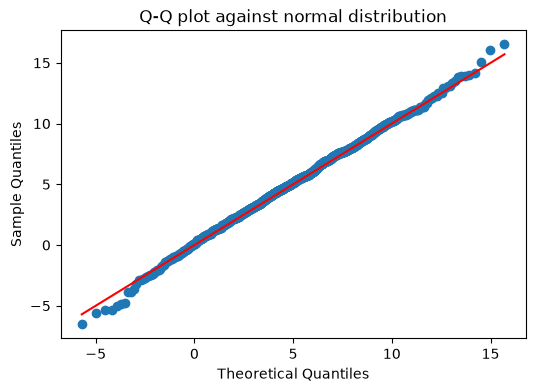

In [5]:
def custom_qqplot_normal2(sample, mu=0, sigma=1):
    n = len(sample)

    ordered = np.sort(sample)
    index = np.arange(1, n + 1)

    probabilities = index / (n + 1)
    th_quantiles = sp.stats.norm.ppf(probabilities, loc=mu, scale=sigma)

    x_line = np.array([th_quantiles.min(), th_quantiles.max()])
    y_line = x_line

    plt.figure(figsize=(6, 4))
    plt.scatter(th_quantiles, ordered)
    plt.plot(x_line, y_line, color="red")
    plt.xlabel("Theoretical Quantiles")
    plt.ylabel("Sample Quantiles")
    plt.title("Q-Q plot against normal distribution")
    plt.show()

custom_qqplot_normal2(norm_sample, mu=mu, sigma=sigma)

## Задача 3. 
Имплементирайте фунцкия, която начертава Q-Q plot на едномерни данни спрямо дадено вероятностно резпределение като втори параметър.

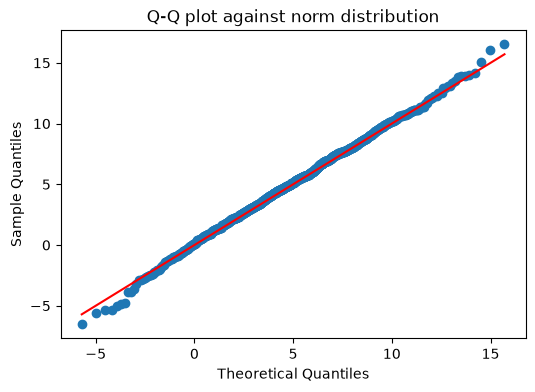

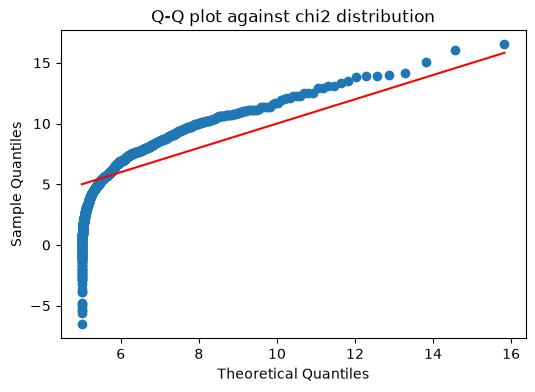

In [6]:
def custom_qqplot(sample, distribution, *args, **kwargs):
    n = len(sample)

    ordered = np.sort(sample)
    index = np.arange(1, n + 1)

    probabilities = index / (n + 1)
    th_quantiles = distribution.ppf(probabilities, *args, **kwargs)

    x_line = np.array([th_quantiles.min(), th_quantiles.max()])
    y_line = x_line

    plt.subplots(figsize=(6, 4))
    plt.scatter(th_quantiles, ordered)
    plt.plot(x_line, y_line, color="red")
    plt.xlabel("Theoretical Quantiles")
    plt.ylabel("Sample Quantiles")
    plt.title(f"Q-Q plot against {distribution.name} distribution")
    plt.show()

custom_qqplot(norm_sample, sp.stats.norm, loc=mu, scale=sigma)
custom_qqplot(norm_sample, sp.stats.chi2, loc=mu, df=1)

## Задача 4.
Генерирайте 100 наблюдения от триъгълно разпределение с параметри (2, 5, 10). Начертайте Q-Q plot на данните спрямо теоретичните квантили, използвайки функцията от зад. 2

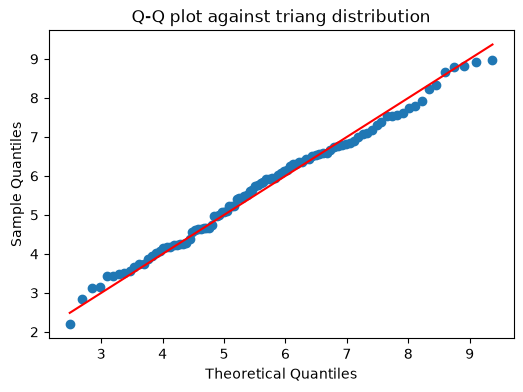

In [7]:
rng = np.random.default_rng(seed=3) # За да възпроизведем резултатите, използваме фиксиран seed

triang_sample = rng.triangular(left=2, mode=5, right=10, size=100)

# Параметрите на триъгълнoто разпределение са: left, mode и right. В нашия случай left=2, mode=5 и right=10.
#
# В документацията на `scipy.stats.triang` пише: 
# 
# "The triangular distribution can be represented with an up-sloping line from loc to (loc + c*scale) 
#  and then downsloping for (loc + c*scale) to (loc + scale)."
# 
# Значи имаме:
# 
# loc = 2 (стартова точка на дистрибуцията)
# 
# right = loc + scale (крайна точка на дистрибуцията) 
#   => scale = 10 - 2
# 
# mode = loc + c*scale (среда на дистрибуцията) 
#   => 5 = 2 + c*(10 - 2) 
#   => c = (5 - 2) / (10 - 2)
custom_qqplot(triang_sample, sp.stats.triang, c=(5 - 2) / (10 - 2), loc=2, scale=10 - 2)


## * Задача 5.
Генерирайте 100 наблюдения от t-разпределението със степен на свобода 5. Начертайте Q-Q plot на данните спрямо теоретичните квантили, използвайки функцията от зад. 2

In [8]:
rng = np.random.default_rng(seed=3) # За да възпроизведем резултатите, използваме фиксиран seed

sample_t = rng.standard_t(df=5, size=100)

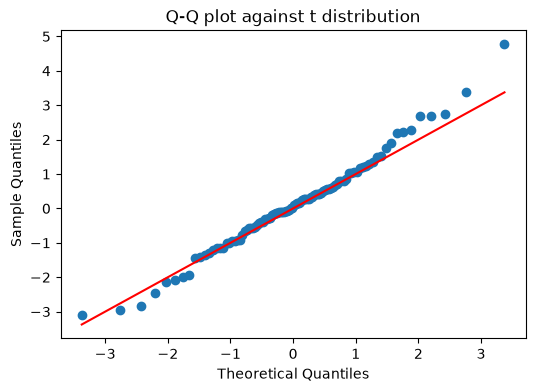

In [9]:
custom_qqplot(sample_t, sp.stats.t, df=5)

## Задача 6. 
Генерирайте 100 наблюдения над случайната величина $X\sim \mathcal{N}_5(\mu, \Sigma)$, където $\mu$ и $\Sigma$ произволни. Тествайте за нормалност чрез Q-Q plot.

Ако данните следват нормално разпределение, квадратите на генерализираните разстояния от средното $d^2_i = (x_i - \bar x)^T S^{-1} (x_i - \bar x)$ следват $\chi^2_p$ разпределение. Следователно, ако пресметнем тези разстояния, можем да тестваме данните за нормалност като тестваме разстоянията за $\chi^2_p$ разпределение.

In [10]:
n = 100
p = 5

# За възпроизводимост
rng = np.random.default_rng(seed=6) 

# Произволен вектор на средните mu
mu = rng.uniform(-5, 5, size=p)

# Произволна положително определена ковариационна матрица Sigma (A * A^T)
A = rng.standard_normal((p, p))
sigma = A @ A.T

X = rng.multivariate_normal(mu, sigma, size=n)
X.shape

(100, 5)

In [11]:
mu_hat = np.mean(X, axis=0)
mu_hat

array([-0.03270925, -1.24963551, -1.75606896, -1.19404797,  5.08741658])

In [12]:
S = np.cov(X, rowvar=False)
print(S.shape)
print(S)

# Алтернативно:
# S = np.dot((X-mu_hat).T, (X-mu_hat)) / (n - 1)
# S

(5, 5)
[[ 5.45308832 -1.55284141  4.7317813  -0.03134503 -4.58445983]
 [-1.55284141  2.66646405 -3.09147688  1.08111087 -0.71598687]
 [ 4.7317813  -3.09147688  7.06228113 -2.30796084 -2.09273045]
 [-0.03134503  1.08111087 -2.30796084  2.79311371 -1.00335648]
 [-4.58445983 -0.71598687 -2.09273045 -1.00335648  5.8627685 ]]


In [13]:
S_inv = np.linalg.inv(S)
print(S_inv.shape)
print(S_inv)

(5, 5)
[[29.82281592 14.44484518 -9.24013627 -5.39725433 20.86238551]
 [14.44484518  8.4955756  -3.48870707 -2.15874864 10.71807888]
 [-9.24013627 -3.48870707  3.78996848  2.25427561 -5.91285117]
 [-5.39725433 -2.15874864  2.25427561  1.78366123 -3.37415542]
 [20.86238551 10.71807888 -5.91285117 -3.37415542 15.10502893]]


In [14]:
def mahalanobis_distance(X, mu_hat, S_inv):
    # A = (X - mu_hat) @ S_inv:
    #   - матрично произведение на матрици (n, p) и (p, p); резултатът е матрица (n, p)
    # B = A * (X - mu_hat):
    #   - покомпонентно (елементно) умножение на матрици (n, p) и (n, p); резултатът е матрица (n, p)
    # C = np.sum(B, axis=1):
    #   - сумиране по колони на матрица (n, p); резултатът е вектор (n,)
    return np.sum(((X - mu_hat) @ S_inv) * (X - mu_hat), axis=1)

d = mahalanobis_distance(X, mu_hat, S_inv)
d.shape

(100,)

<Axes: ylabel='Count'>

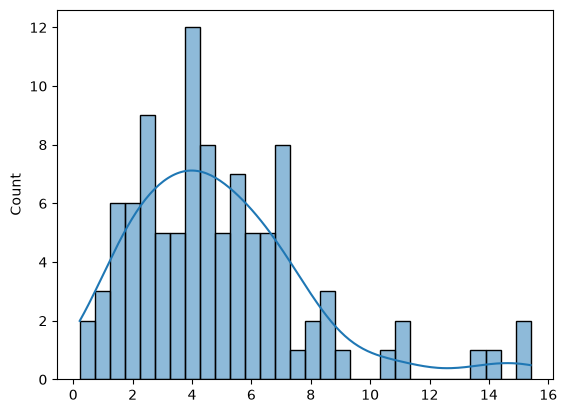

In [15]:
sb.histplot(x=d, bins=30, kde=True)

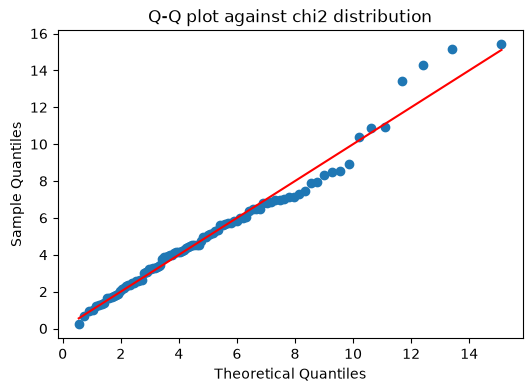

In [16]:
custom_qqplot(d, sp.stats.chi2, df=p)

In [17]:
# Тест на Колмогоров-Смирнов за съвпадение на разпределенията
# Това е само приблизителен тест! Когато средните и ковариационната матрица са оценени от данните, резултатите не са точни.
# Генерализараните разстояния следват χ²-разпределението само приблизително. Визуалният тест в такъв случай е достатъчен.
# По-надежден и точен тест е Ханс-Зирклер, който ще разгледаме по-късно.
result = sp.stats.kstest(d, sp.stats.chi2.cdf, args=(p,))

print(f"KS statistic: {result.statistic}")
print(f"p-value:      {result.pvalue}")

KS statistic: 0.06086791333562014
p-value:      0.8304742286539459


## Задача 7.
Тествайте данните във файла 'data/lumber_stiffness.csv':
1. За нормалнмост чрез Q-Q плот
2. За екстремални стойности (outliers) като пресметнете квадратите на генерализираните разстояния (които са разпределени като $\chi^2_p$) и ги сравните с критичната стойност $\chi^2_{p, 0.02}$

In [18]:
data  = pd.read_csv('data/lumber_stiffness.csv', header=None)

X = data.to_numpy()

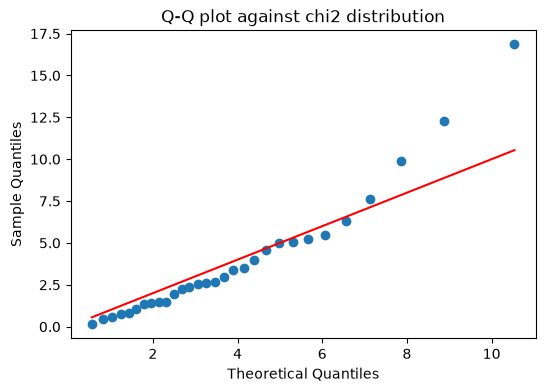

In [19]:
# Визуален тест за нормалност
mu_hat = np.mean(X, axis=0)
S_inv = np.linalg.inv(np.cov(X, rowvar=False))
d = mahalanobis_distance(X, mu_hat, S_inv)

custom_qqplot(d, sp.stats.chi2, df=X.shape[1])

In [20]:
# Teст за екстремални стойности
chi_p02 = sp.stats.chi2.ppf(0.98, df=X.shape[1])
outlier_idx = np.where(d > chi_p02)
outliers = d[outlier_idx]
outliers

array([12.26475499, 16.84740702])

## ** Задача 7.
Начертайте scatterpolts между промеливите от данните в предишната задача (общо 12 плота). Оцветете екстремалните стойности в различен цвят. (фиг. 4.11 от учебника Applied Multivariate Statistical Analysis, Johnson & Wichern)

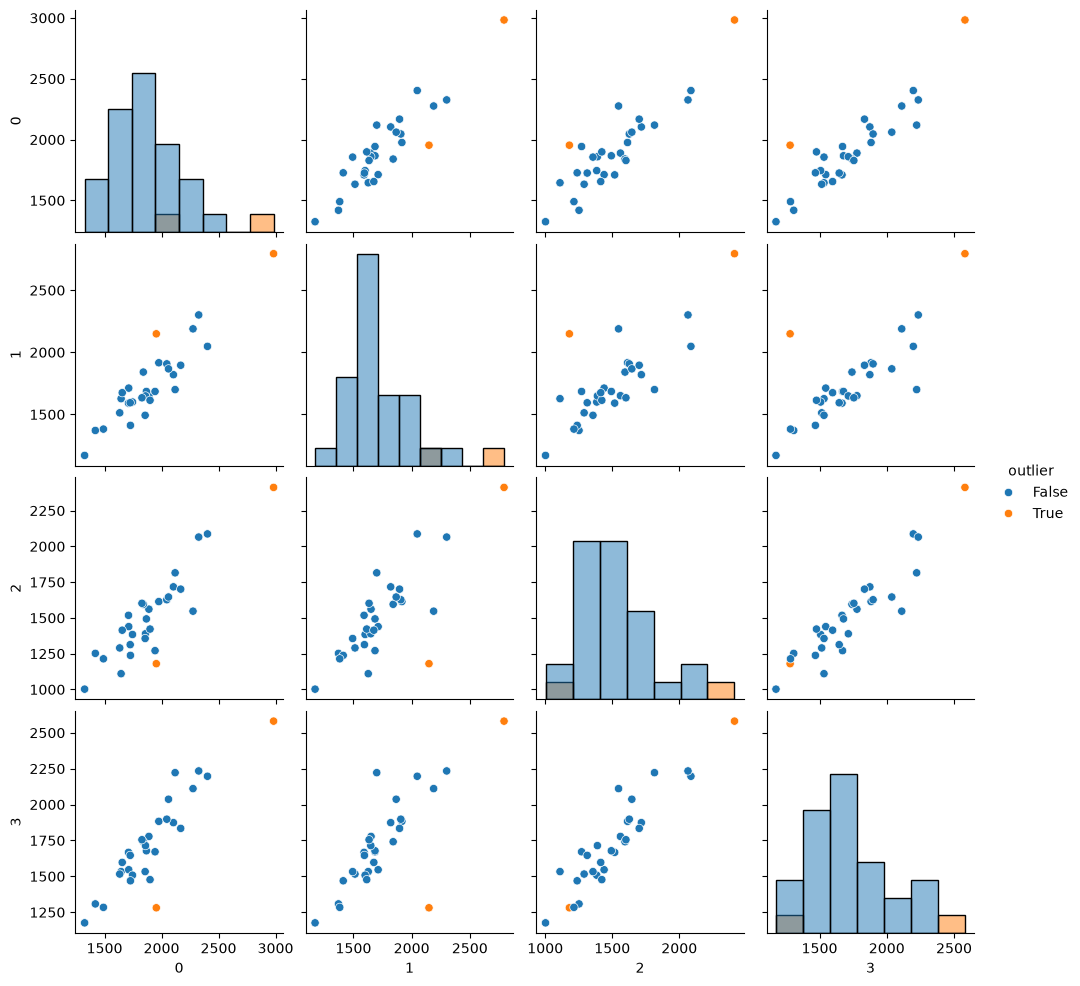

In [21]:
data['outlier'] = d > chi_p02

sb.pairplot(data=data, hue='outlier', diag_kind='hist')

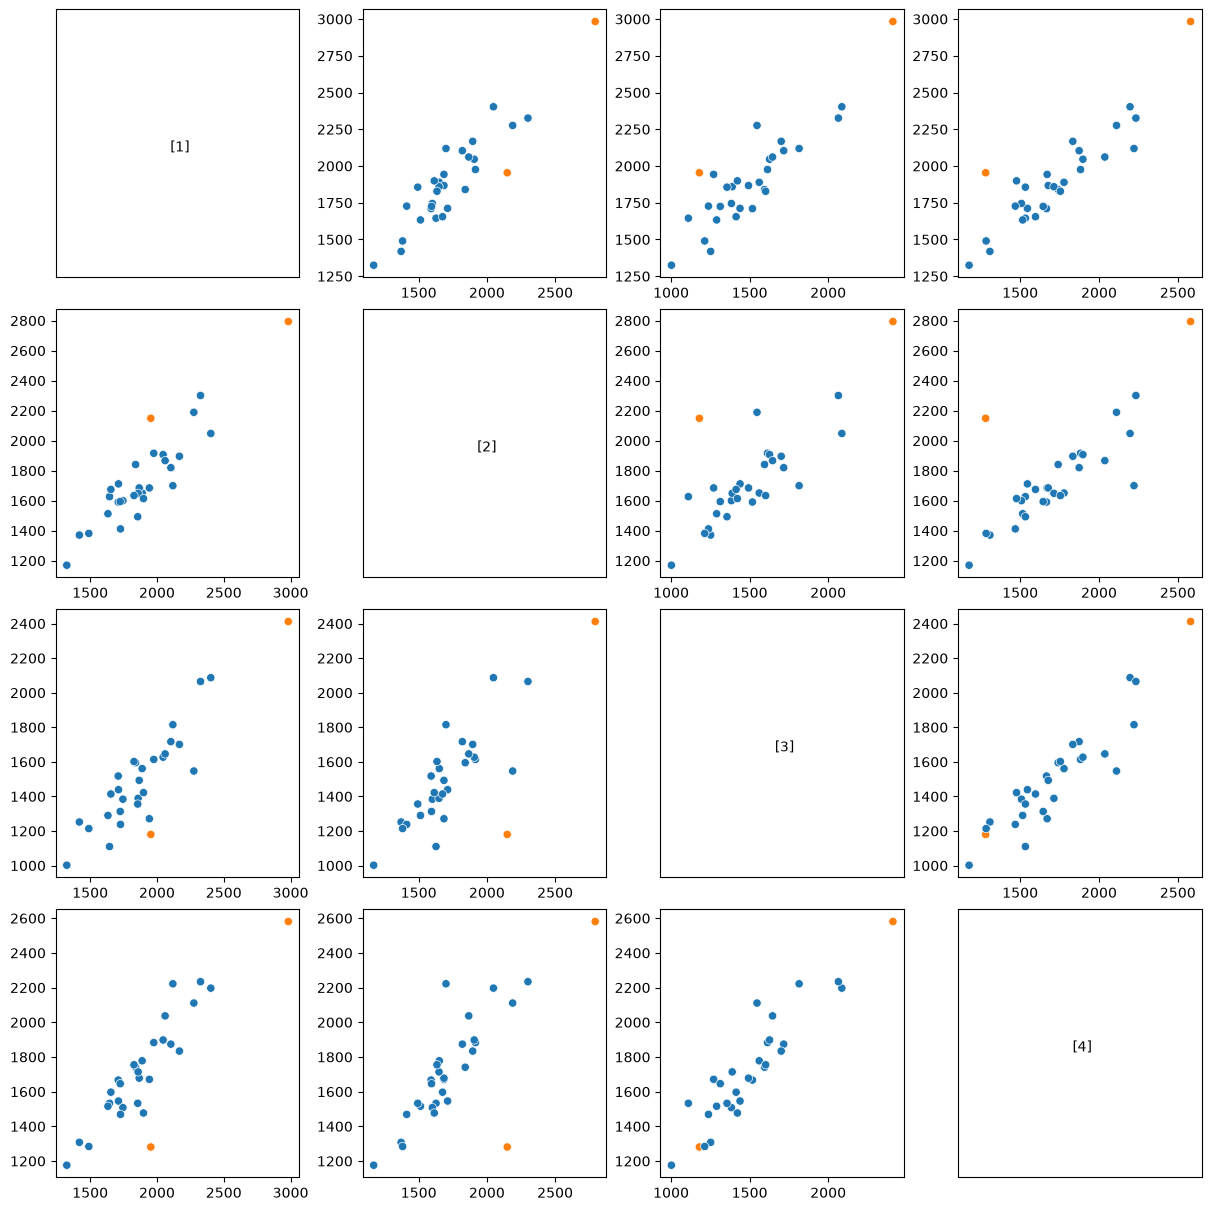

In [22]:
def pairplot(data, hue=None):
    _, axes = plt.subplots(nrows=data.shape[1], ncols=data.shape[1], figsize=(12, 12), layout='constrained')
    
    for ridx in range(data.shape[1]):
        for cidx in range(data.shape[1]):
            ax = axes[ridx, cidx]
            
            if ridx == cidx:
                ax.text(0.47, 0.47, f'[{ridx + 1}]')
                
                ax.set_xticks([])
                ax.set_yticks([])
            else:
                sb.scatterplot(x=data.iloc[:, cidx], y=data.iloc[:, ridx], hue=hue, ax=ax, legend=False)
          
            ax.set_xlabel('')
            ax.set_ylabel('')
                
                
pairplot(data=data.drop(columns=['outlier']), hue=data['outlier'])